In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import CubicSpline

import ipywidgets as widgets
from IPython.display import display, clear_output

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


What are **os** and **glob**?

**os** is used for file path and folder operations, it is basically helping Python deal with folder paths safely
* it is used further down when getting the base name of the files and creating the save path.
* for example, instead of manually writing: "C:\folder\subfolder\file.dat", you can use os to: os.path.join(folder_path,file_name), telling Python to combine the folder path and the filename into one valid path

**glob** is used to find files that match a particular pattern
* for example, dat_files = glob.glob(os.path.join(folder_path, "*.dat")) is telling Python to look inside folder_path and find every file that ends in .dat where the * could be anything
* glob.glob returns a list of the files.

---


def plot_dat_with_convolution takes:
* the specific .dat file being processed
* the out put folder where the cleaned/convolved data will be saved
* sigma for the Gaussian smoothing
* multiplier applied after smoothing
* the number of points used for the interpolation

std_dev controls the Gaussian smoothing, height_factor scales the smoothed Y-values up or down after the smoothing (=1, does nothing), and num_interp_points controls how many points are generated for the smoother interpolated curve.

Order of signal processing: original y-data -> gaussian smoothing -> height scaling -> cubic spline interpolation -> peak finding

Overall, the Gaussian smoothing replaces each y-value with a weighted average of itself and nearby y-values, where close points matter more than farther points. The weights are shapped like a Gaussian curve.

Gaussian and interpolation flow: original X and original Y -> original X and gaussian smoothed Y -> build cubic spline curve -> evaluate the curve on many more X-points
* done because peak detection and peak spacing can be more precise when the curve has a very fine X-resolution, and conceptually this interpolation is not new experimental data, it is a smooth mathematical estimate between your measured point

In [3]:
def plot_dat_with_convolution(file_path, output_folder, std_dev=2, height_factor=1, num_interp_points=10000):
    """Processes a single .dat file as before, but saves convolved data automatically."""

    # Read the .dat file
    # opening file, reading every line, and storing all lines in a list called
    # lines
    with open(file_path, 'r') as file:
        lines = file.readlines()

    datasets = [] # the list of completed data sets
    current_data = [] # the dataset currently being built

    # reading line by line
    # if the line is numeric, add it to the current_data
    # if the line is blank/header/non-numeric, the the current dataset is done,
    # and save it into datasets

    for line in lines:
        # going one line at a time through the files
        stripped = line.strip() # strip removes extra spaces and line breaks

        # checking if the line is empty OR in the line does not contain digits
        if not stripped or not any(char.isdigit() for char in stripped):
            if current_data:
                # if collecting numeric rows, turn them into DataFrame, store
                # the completed dataset, then reset current_data to start
                # the next data set
                datasets.append(pd.DataFrame(current_data, columns=["X", "Y"]))
                current_data = []
            continue

        # when it finds a numeric line, stripped.split() splits the line by spaces
        # map(float, ....) turns the text values into actual numbers, so string to num
        try:
            values = list(map(float, stripped.split()))
            if len(values) >= 2:
                # if the line has at least two numbers, keep only the first two
                # and add them to the current dataset
                # if the line only has "Mag1" and it is here, it wont append it,
                # even though there is a number in it
                current_data.append(values[:2])
        except ValueError:
            continue

    # repeated after the look to catch the last data set
    # the earlier code only saves a dataset when it hits a blank/header/non-data line
    # but if the file ends immediately after the last numeric row, it doesnt
    # get saved there, so this portion purposefully calls that last row
    if current_data:
        datasets.append(pd.DataFrame(current_data, columns=["X", "Y"]))

    #stores the spacing between peaks from all datasets
    all_peak_deltas = []

    # getting the base name of the files by replacing .dat to _convolved.dat
    # then creates the whole output path for the concolved data
    base_name = os.path.basename(file_path).replace(".dat", "_convolved.dat")
    save_path = os.path.join(output_folder, base_name)

    with open(save_path, 'w') as save_file:
        # opens the output file for writing, then process each dataset one by one
        # enumerate(datasets) give both idx=dataset number and df=the actual DataFrame
        # Dataset idx+1
        for idx, df in enumerate(datasets):
            # pulling the two columns, x=frequency, y=magnitude
            x_values = df["X"].values
            y_values = df["Y"].values

            # GAUSSIAN SMOOTHING
            # this smoothes the y values using a Gaussian curve
            # replaces each y-value with a weighted avergae of itself and nearby
            # y-values, where closer points matter more than farther points
            # sigma controls how wide the smoothing window is,
            # small sigma -> less smoothing, large sigma -> more smoothing
            # height_factor multiplies the smoothed signal, does nothing @ 1
            y_convolved = gaussian_filter1d(y_values, sigma=std_dev) * height_factor

            # INTERPOLATION
            # this creates a new X-axis with num_interp_points between the min
            # and max values, giving it the code and data a much denser x-grid
            x_interp = np.linspace(x_values.min(), x_values.max(), num_interp_points)

            # creates a smooth curve through the smoothed data and evaluated that
            # curve at the new num_interp_points x-points
            spline = CubicSpline(x_values, y_convolved)
            y_convolved_interp = spline(x_interp)

            # PEAK FINDING
            # find_peaks(...) find the local maxima in the interpolated smoothed curve
            peaks, _ = find_peaks(y_convolved_interp)
            # getting the x and y coordinates of the peaks
            peak_x = x_interp[peaks]
            peak_y = y_convolved_interp[peaks]

            # PEAK SPACING
            # calculates the difference between neighboring peak X-values
            delta_x_full = np.diff(peak_x)
            all_peak_deltas.append(delta_x_full)


            # SAVING CONVOLVED DATA
            # np.column_stack put the x and y columns next to eachother
            # np.savetext write that into a .dat file
            save_file.write(f"# Convolved Data (Dataset {idx+1})\n")
            np.savetxt(save_file, np.column_stack((x_interp, y_convolved_interp)), fmt="%.6f", delimiter="\t")
            save_file.write("\n")

            # Plotting
            plt.figure(figsize=(8, 5))
            plt.plot(x_values, y_values, 'b-', label=f'Original Data {idx+1}', alpha=0.6)
            plt.plot(x_interp, y_convolved_interp, 'r-', linewidth=2, label='Gaussian Convolution (Interpolated)')
            plt.scatter(peak_x, peak_y, color='magenta', marker='o', label='Peaks')
            plt.xlabel("X Values")
            plt.ylabel("Y Values")
            plt.title(f"{os.path.basename(file_path)} - Dataset {idx+1}")
            plt.legend()
            plt.grid(True)
            plt.show()

            # ZOOM CONTROLS
            # creating the widgets that can be editted to zoom into the data after plotting
            xmin_box = widgets.FloatText(value=float(x_values.min()), description='xmin:')
            xmax_box = widgets.FloatText(value=float(x_values.max()), description='xmax:')
            button = widgets.Button(description="Show zoomed plot")
            # every time the button is clicked, a new output window can appear
            # in the same place as the old one
            output = widgets.Output()

            # function in a function defining what happens when you click the button
            # b is just information about the button click, the widget system
            # passes the b automatically
            def show_zoomed_plot(b):
                with output:
                    # shows the next plot inside the widget output area and
                    # clears the old zoomed plot
                    clear_output(wait=True)

                    # reading values from the text boxes
                    xmin = xmin_box.value
                    xmax = xmax_box.value

                    # keeping the original data points where x is between xmin xmax
                    mask_original = (x_values >= xmin) & (x_values <= xmax)
                    x_original_zoomed = x_values[mask_original]
                    y_original_zoomed = y_values[mask_original]

                    # keeping the convolved data points where x is between xmin xmax
                    mask_convolved = (x_interp >= xmin) & (x_interp <= xmax)
                    x_zoomed = x_interp[mask_convolved]
                    y_zoomed = y_convolved_interp[mask_convolved]

                    # finding the local maxima in the zoomed concolved data
                    zoomed_peaks, _ = find_peaks(y_zoomed)
                    zoomed_peak_x = x_zoomed[zoomed_peaks]
                    zoomed_peak_y = y_zoomed[zoomed_peaks]

                    # plotting
                    plt.figure(figsize=(8, 5))
                    plt.plot(x_original_zoomed, y_original_zoomed, 'b-', label='Original Data', alpha=0.6)
                    plt.plot(x_zoomed, y_zoomed, 'r-', linewidth=2, label='Zoomed Convolution')
                    plt.scatter(zoomed_peak_x, zoomed_peak_y, color='magenta', marker='o', label='Zoomed Peaks')
                    plt.xlabel("X Values")
                    plt.ylabel("Y Values")
                    plt.title(f"Zoomed Plot (X: {xmin} to {xmax})")
                    plt.legend()
                    plt.grid(True)
                    plt.show()

            # calling the show zoomed_plot_function by the button click
            button.on_click(show_zoomed_plot)

            # shows the boxes and buttons in Colab
            display(widgets.HBox([xmin_box, xmax_box, button]))

            # shows where the zoomed plot will appear
            display(output)

    # combines all the peak spacing arrays from all datasets into one big array
    # although nothing is really done with this since the convolved data
    # gets stored in the output file
    all_peak_deltas = np.concatenate(all_peak_deltas) if all_peak_deltas else np.array([])
    return all_peak_deltas

def process_all_dat_files_in_folder takes:
* the folder path where the raw data is
* takes the output folder where the covolved data will go

basically a batch-processing wrapper

In [4]:
def process_all_dat_files_in_folder(folder_path, output_folder):
    # creating the output folder if it doesn't already exist
    # exist_ok=True means that if the folder exists, done crash or throw and error
    os.makedirs(output_folder, exist_ok=True)

    # os.path.join() creates a search pattern looking for .dat files
    # glob.glob finds the mathing files
    dat_files = glob.glob(os.path.join(folder_path, "*.dat"))

    print(f"Found {len(dat_files)} .dat files in: {folder_path}\n")

    # looping through all found files
    for file_path in dat_files:
        print(f"Processing: {file_path}")
        # sending one .dat file at a time to the processing function
        # deltas not used after here, only convolved data is saved
        deltas = plot_dat_with_convolution(file_path, output_folder)

Found 5 .dat files in: /content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2

Processing: /content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2/175batch1_col1.dat


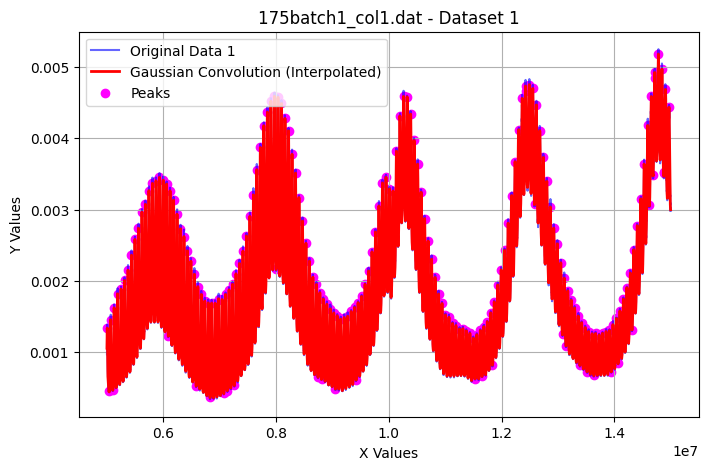

Output()

Processing: /content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2/175batch1_col2.dat


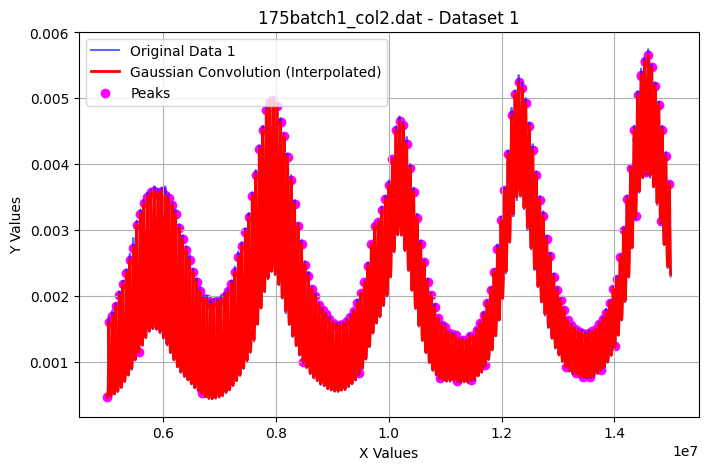

Output()

Processing: /content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2/175batch1_col4.dat


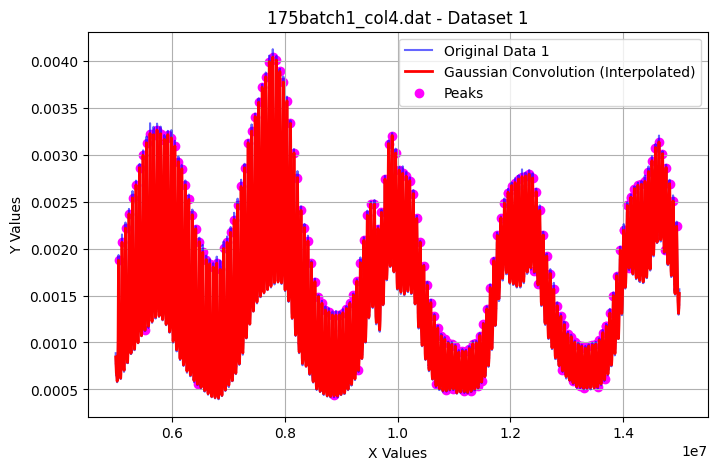

Output()

Processing: /content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2/175batch1_col3.dat


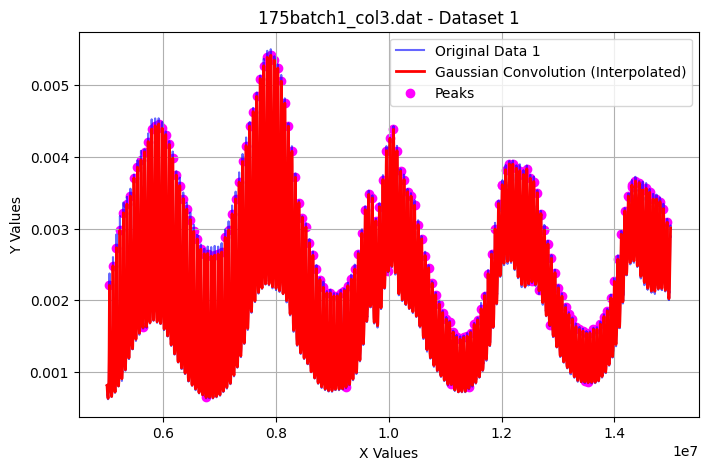

Output()

Processing: /content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2/175batch1_col5.dat


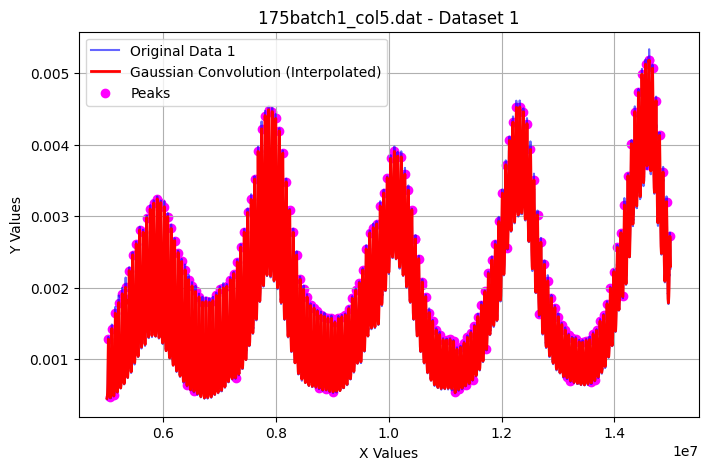

Output()

In [5]:
# r before the string just means raw string, python sometimes treats backslashes
# as special characters, and the r prevents that problem
folder_path = r'/content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/RawData2'
output_folder = r'/content/drive/MyDrive/PhD_GoogleColab/175 Tests/080625/Batch1/CleanData2'

process_all_dat_files_in_folder(folder_path, output_folder);